# Exploratory Data Analysis (EDA)
## Mental Health & Crisis Signal Mining on Social Media
**CMPE 255 – Section 34, Spring 2026**

This notebook loads and explores the three Kaggle datasets used in this project:
1. **Reddit Mental Health Dataset** (`data_to_be_cleansed.csv`)
2. **Sentiment Analysis for Mental Health** (`Combined Data.csv.csv`)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load Datasets

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Dataset Depression & Anxiety (Social Media)
df_text = pd.read_csv('/content/drive/MyDrive/Combined Data.csv')
df_text = df_text.drop(columns=['Unnamed: 0'], errors='ignore')

print(f'Depression & Anxiety: {df_text.shape}')

# Report nulls before dropping
print(f'\nNull text rows Text: {df_text["statement"].isnull().sum()}')

# Drop rows with null text
df_text = df_text.dropna(subset=['statement'])

print(f'\nAfter dropping nulls:')
print(f'Mental Health text {df_text.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Depression & Anxiety: (53043, 2)

Null text rows Text: 362

After dropping nulls:
Mental Health text (52681, 2)


## 2. Dataset Mental Health on Social Media

In [4]:
print('Columns:', df_text.columns.tolist())
print(f'\nShape: {df_text.shape}')
print(f'\nNull counts:')
print(df_text.isnull().sum())
print(f'\nDuplicates: {df_text.duplicated(subset=["statement"]).sum()}')
df_text.head(3)

Columns: ['statement', 'status']

Shape: (52681, 2)

Null counts:
statement    0
status       0
dtype: int64

Duplicates: 1608


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


Label value counts:
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64



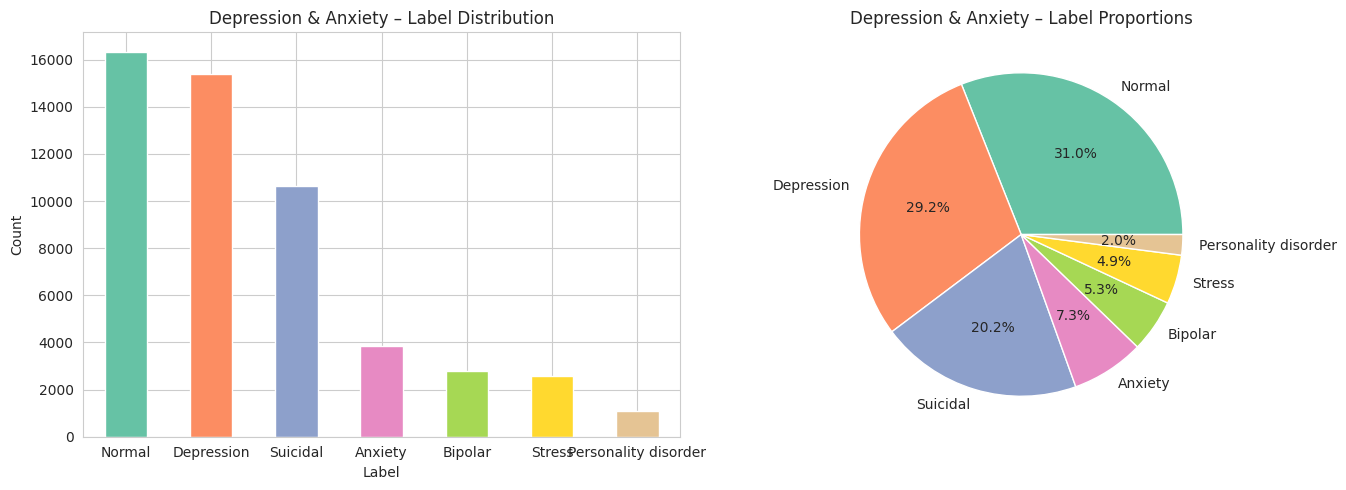

In [5]:
# Label distribution
print('Label value counts:')
print(df_text['status'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_text['status'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Depression & Anxiety – Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_text['status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Depression & Anxiety – Label Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

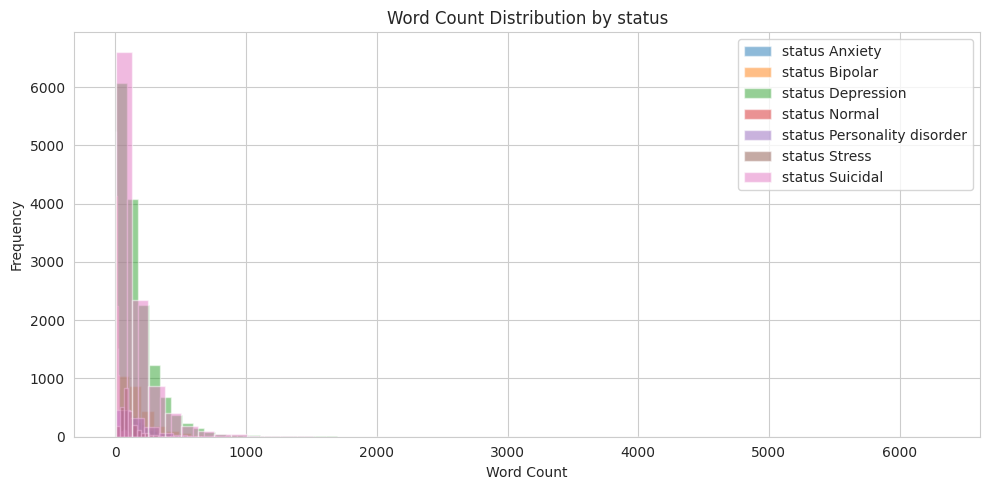

Word count statistics by status:
                        count   mean    std  min   25%    50%    75%     max
status                                                                      
Anxiety                3841.0  143.8  152.6  1.0  41.0  102.0  192.0  1592.0
Bipolar                2777.0  176.2  176.5  4.0  74.0  129.0  220.0  4804.0
Depression            15404.0  168.0  188.2  1.0  54.0  113.0  215.0  4239.0
Normal                16343.0   17.2   22.8  1.0   6.0   10.0   18.0   255.0
Personality disorder   1077.0  179.3  221.9  5.0  66.0  137.0  236.0  5419.0
Stress                 2587.0  114.6  105.9  1.0  64.0   87.0  127.0  1606.0
Suicidal              10652.0  146.4  187.0  1.0  42.0   92.0  186.0  6300.0


In [6]:
# Post length analysis
df_text['word_count'] = df_text['statement'].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
for label in sorted(df_text['status'].unique()):
    subset = df_text[df_text['status'] == label]
    ax.hist(subset['word_count'], bins=50, alpha=0.5, label=f'status {label}')

ax.set_title('Word Count Distribution by status')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print('Word count statistics by status:')
print(df_text.groupby('status')['word_count'].describe().round(1))

In [7]:
# Sample posts
for label in sorted(df_text['status'].unique()):
    print(f'\n{"="*60}')
    print(f'LABEL = {label}')
    print(f'{"="*60}')
    sample = df_text[df_text['status'] == label].sample(2, random_state=42)
    for _, row in sample.iterrows():
        text = str(row['statement'])[:300]
        print(f'\nText: {text}')
        print(f'Word count: {row["word_count"]}')


LABEL = Anxiety

Text: Is this health anxiety? 1) checking temperature 10 times a day
2) checking blood pressure everyday
3) checking weight 10 times a day

Thinking I might have a serious disease
Word count: 30

Text: Is there any way to sleep better? I can't sleep most of the nights, meds didn't help.
Word count: 17

LABEL = Bipolar

Text: Positive Affirmations/Pep Talks/Success stories I'm having a pretty rough night/week and I'm getting overwhelmed about it. Rather than ask for advice, I'd love some positive affirmations that you guys have for yourselves, what pep talks you've used to get you through rough spots, or something you we
Word count: 71

Text: Vraylar/Reagila.. restlessness, any tips? I started Reagila a month ago and I can't get rid of the restlessness. The first two weeks were horror with side effects, thank God the shaking stopped. But this restlessness is driving me crazy - literally lack of sleep is usually the best way for me to get
Word count: 183

LABEL = Depres

In [8]:
import os

# Define paths for saving the cleaned data
output_dir = '/content/drive/MyDrive/'

# Save df_text
df_text_output_path = os.path.join(output_dir, 'df_text_cleaned.csv')
df_text.to_csv(df_text_output_path, index=False)
print(f'Cleaned df_text saved to: {df_text_output_path}')


Cleaned df_text saved to: /content/drive/MyDrive/df_text_cleaned.csv
